In [1]:
import numpy as np
import pandas as pd
import torch
import h5py
import joblib
import os, sys
import subprocess
import matplotlib.pyplot as plt
import math, json

In [2]:
sys.path.insert(0, "/mnt/efsUCE/umap_pytorch")  #git+https://github.com/ucscBrainExplorer/umap_pytorch.git
import umap_pytorch
print(umap_pytorch.__file__)

/mnt/efsUCE/umap_pytorch/umap_pytorch/__init__.py


In [70]:
results_dir = "Wang2025Nature"

embedding_h5_file = "pca.h5"
embedding_h5_file_key = "pca"
knn_outfile = "knn_30.npz"
k = 10
#k = 15

existing_model_iteration = 80
epochs = 15

## Load Embedding back into memory

In [4]:
# Load the embedding data
# Open the HDF5 file
with h5py.File(os.path.join(results_dir, embedding_h5_file), "r") as f:
    X_data = f[embedding_h5_file_key][:]

# Convert to PyTorch tensor so to use gpu
data_tensor = torch.from_numpy(X_data)
data_tensor, data_tensor.shape

(tensor([[ 3.4851e-01, -7.2028e-02,  1.9266e-01,  ..., -3.8041e-02,
           2.8093e-02,  2.1752e-02],
         [ 4.3125e-01,  1.3438e-01,  1.5351e-01,  ..., -1.9471e-02,
           3.9879e-02,  9.1036e-02],
         [ 3.5475e-01, -6.4740e-02,  1.8698e-01,  ...,  1.7600e-02,
           1.2234e-03,  1.8626e-02],
         ...,
         [ 6.6610e-02, -2.6420e-01,  8.6320e-02,  ..., -2.6212e-02,
          -4.5116e-03,  2.5040e-02],
         [-1.9914e-01, -1.6261e-01, -6.9311e-02,  ...,  2.6953e-02,
           1.0302e-01,  3.6196e-02],
         [-1.7761e-02, -3.6489e-01,  9.4060e-02,  ...,  7.6250e-05,
          -1.4281e-02,  2.1983e-03]]),
 torch.Size([232328, 50]))

## Load Knn Back

In [6]:
# load knn back
data = np.load(os.path.join(results_dir, knn_outfile))
knn_indices = data["indices"]
knn_distances = data["distances"]

In [7]:
knn_distances = np.sqrt(knn_distances)

## PUMAP 
using umap_pytorch https://github.com/ucscBrainExplorer/umap_pytorch.git

## set up training on all cells

In [8]:
knn_indices = knn_indices[:,:k]
knn_dists = knn_distances[:,:k]

### Load model back or start with a new model

In [71]:
if existing_model_iteration > 0:
    from umap_pytorch import load_pumap
    path = os.path.join(results_dir, f'pytorch_e{existing_model_iteration}.pkl')
    pumap = load_pumap(path)
    pumap.epochs = epochs
    print ("Start with existing model", f'pytorch_e{existing_model_iteration}.pkl')
else:
    import torch.nn.functional as F
    pumap = umap_pytorch.PUMAP(
        encoder=None,           # nn.Module, None for default
        decoder=None,           # nn.Module, True for default, None for encoder only
        n_neighbors=10,
        min_dist= 0.1,
        metric="euclidean",
        n_components=2,
        beta=1.0,               # How much to weigh reconstruction loss for decoder
        reconstruction_loss=F.binary_cross_entropy_with_logits, # pass in custom reconstruction loss functions
        random_state=None,
        lr=1e-3,
        epochs=epochs, #5,
        batch_size= 512, #256, #64, # gpu memory related
        num_workers=0, #10,
        num_gpus=1,
        match_nonparametric_umap=False, # Train network to match embeddings from non parametric umap,
    )
    print ("Start with a new model")

Loading PUMAP object from pickled file.
Start with existing model pytorch_e80.pkl


### Train

In [72]:
existing_model_iteration, pumap.epochs

(80, 15)

In [73]:
np.product = np.prod  # alias to fix compatibility
pumap.fit(data_tensor, knn_indices, knn_dists)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Fitting parametric Umap
There are knn provided by the user
Start fuzzy_simplicial_set ...
End fuzzy_simplicial_set
Training start
Start UMAPDataset initiation ...
batch_size: 512
End UMAPDataset. 274670016 232328


/mnt/efsUCE/umap_pytorch/umap_pytorch/data.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.data = torch.tensor(data, device="cuda")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type            | Params | Mode 
----------------------------------------------------
0 | encoder | default_encoder | 91.0 K | train
----------------------------------------------------
91.0 K    Trainable params
0         Non-trainable params
91.0 K    Total params
0.364     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


dataloader len: 453


/home/ec2-user/.local/lib/python3.9/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                   …

`Trainer.fit` stopped: `max_epochs=15` reached.


### Saving model

In [74]:
existing_model_iteration = existing_model_iteration+ pumap.epochs
existing_model_iteration

95

In [75]:
model_path = os.path.join(results_dir, f'pytorch_e{existing_model_iteration}.pkl')
pumap.save(model_path)

Pickled PUMAP object at Wang2025Nature/pytorch_e95.pkl


### Quick viz X_umap_pytorch

In [76]:
existing_model_iteration

95

In [77]:
# load model
from umap_pytorch import load_pumap
model_path = os.path.join(results_dir, f'pytorch_e{existing_model_iteration}.pkl')
pumap = load_pumap(model_path)
print("Loaded model", f'pytorch_e{existing_model_iteration}.pkl')

Loading PUMAP object from pickled file.
Loaded model pytorch_e95.pkl


#### random 1M

In [78]:
view_size = 1_000_000
if X_data.shape[0] < view_size:
    subset_indices = range (0, X_data.shape[0])
else:
    np.random.seed(42)  # set seed for reproducibility
    subset_indices = np.random.choice(X_data.shape[0], size= view_size, replace=False)

In [79]:
X_umap_pytorch = pumap.transform(data_tensor[subset_indices])

Reducing array of shape torch.Size([232328, 50]) to (232328, 2)


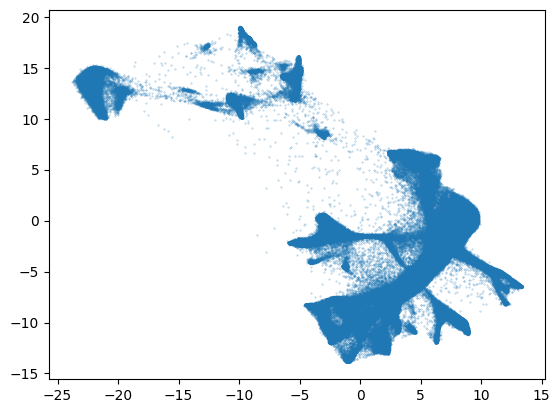

In [80]:
# current
plt.scatter(X_umap_pytorch[:,0], X_umap_pytorch[:,1], alpha =0.5, s=0.1)
plt.show()

### Save UMAP

In [82]:
n_samples = data_tensor.shape[0]
embedding_dim = 2  # since n_components=2
X_umap_pytorch = np.zeros((n_samples, embedding_dim), dtype=np.float32)

# --- Batch transform ---
print("Starting batch transformation ...", flush=True)
batch_size = 1_000_000
for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    batch = data_tensor[start:end]
    emb = pumap.transform(batch)
    X_umap_pytorch[start:end] = emb
    print(f"Processed {end}/{n_samples}", flush=True)

Starting batch transformation ...
Reducing array of shape torch.Size([232328, 50]) to (232328, 2)
Processed 232328/232328


In [83]:
config = {}
model_path = os.path.join(results_dir, f'pytorch_e{existing_model_iteration}.pkl')
config["pumap_model_file"] = model_path
config["pca_model_file"]= os.path.join(results_dir,"ipca_model.pkl") # hard-coded for ipca transformation
config["knn_k"] = 30
config["knn_nprobe"] = 20
config["pca_n_components"] =50

# --- Axis adjustment ---
UMAP1_size = np.ptp(X_umap_pytorch[:, 0])
UMAP2_size = np.ptp(X_umap_pytorch[:, 1])
if UMAP1_size < UMAP2_size:
    print("Swapping axes (too tall UMAP)...", flush=True)
    X_umap_pytorch[:, [0, 1]] = X_umap_pytorch[:, [1, 0]]
    config["swap_xy_matrix"] =  [
        [0, 1],
        [1, 0]
    ]
else:
    config["swap_xy_matrix"] =  [
        [1, 0],
        [0, 1]
    ]
config["PUMAP_k"]=k
config

{'pumap_model_file': 'Wang2025Nature/pytorch_e95.pkl',
 'pca_model_file': 'Wang2025Nature/ipca_model.pkl',
 'knn_k': 30,
 'knn_nprobe': 20,
 'pca_n_components': 50,
 'swap_xy_matrix': [[1, 0], [0, 1]],
 'PUMAP_k': 10}

In [84]:
# --- Saveing transformation config ----
config_path = os.path.join(results_dir, f"transform_e{existing_model_iteration}.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

In [85]:
# --- Save umap ----
umap_file = f"umap_e{existing_model_iteration}.npy"
output_path = os.path.join(results_dir, umap_file)
np.save(output_path, X_umap_pytorch)

## optional quick viz with metadata

In [20]:
metadata_file = "obs_annotated.tsv.gz"
metadata = pd.read_csv(os.path.join(results_dir, metadata_file), sep ='\t')

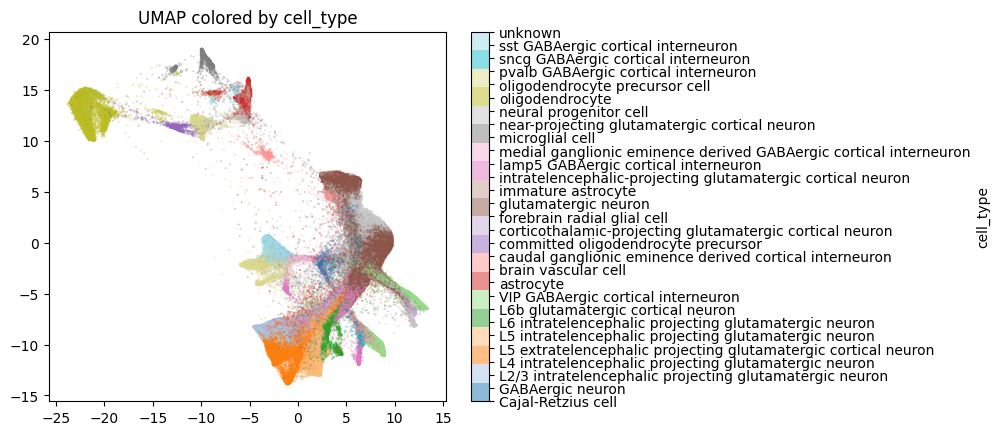

In [81]:
metadata_feature = "cell_type"
max_categories_for_legend = 30  # Adjust this threshold

colors = metadata[metadata_feature].iloc[subset_indices]
categories = colors.astype('category')
category_codes = categories.cat.codes

cmap = plt.get_cmap('tab20')
scatter = plt.scatter(X_umap_pytorch[:, 0], X_umap_pytorch[:, 1],
                     c=category_codes, alpha=0.5, s=0.1, cmap=cmap)

# Only show legend if categories are manageable
n_categories = len(categories.cat.categories)
if n_categories <= max_categories_for_legend:
    cbar = plt.colorbar(scatter, ticks=np.arange(n_categories))
    cbar.set_label(metadata_feature)
    cbar.ax.set_yticklabels(categories.cat.categories)
else:
    print(f"Too many categories ({n_categories}) - legend hidden")
    plt.colorbar(scatter, label=f"{metadata_feature} (numeric codes)")

plt.title(f"UMAP colored by {metadata_feature}")
plt.show()